In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

tickers = ["HDFCBANK.NS", "RELIANCE.NS", "INFY.NS", "ITC.NS", "SUNPHARMA.NS", "LT.NS"]
start_date = "2019-01-01"

In [4]:
prices = yf.download(tickers, start=start_date)["Close"]
prices.to_csv("../data/prices.csv")

print(prices.shape)
print(prices.isna().sum())
prices.tail()

[*********************100%***********************]  6 of 6 completed


(1911, 6)
Ticker
HDFCBANK.NS     0
INFY.NS         0
ITC.NS          0
LT.NS           0
RELIANCE.NS     0
SUNPHARMA.NS    0
dtype: int64


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SUNPHARMA.NS
Date,,,,,,
2026-09-14,708.250000,1037.699951,259.850006,3930.699951,1257.500000,1840.000000
2026-09-15,716.549988,1077.000000,258.000000,3850.699951,1235.300049,1835.000000
2026-09-16,721.500000,1060.000000,264.149994,3807.699951,1240.000000,1853.500000
2026-09-17,713.000000,1058.599976,266.200012,3836.199951,1243.900024,1867.300049
2026-09-18,731.000000,1051.400024,262.299988,3885.000000,1226.400024,1837.300049


In [5]:
returns = prices.pct_change().dropna()
returns.tail()

Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SUNPHARMA.NS
Date,,,,,,
2026-09-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-09-15,0.011719,0.037872,-0.007120,-0.020353,-0.017654,-0.002717
2026-09-16,0.006908,-0.015785,0.023837,-0.011167,0.003805,0.010082
2026-09-17,-0.011781,-0.001321,0.007761,0.007485,0.003145,0.007445
2026-09-18,0.025245,-0.006801,-0.014651,0.012721,-0.014069,-0.016066


In [6]:
summary = pd.DataFrame({
    "mean_daily": returns.mean(),
    "vol_daily": returns.std(),
    "vol_annual": returns.std() * np.sqrt(252),
    "skew": returns.skew(),
    "excess_kurtosis": returns.kurt(),
})
summary

,mean_daily,vol_daily,vol_annual,skew,excess_kurtosis
Ticker,,,,,
HDFCBANK.NS,0.000326,0.015657,0.248547,-0.068926,8.984892
INFY.NS,0.000504,0.017656,0.280273,-0.327974,8.535793
ITC.NS,0.000265,0.015029,0.238575,-0.430689,10.012347
LT.NS,0.000730,0.017246,0.273770,-0.328994,8.959424
RELIANCE.NS,0.000624,0.017383,0.275948,0.441270,10.062823
SUNPHARMA.NS,0.000925,0.016072,0.255132,0.253953,6.004236


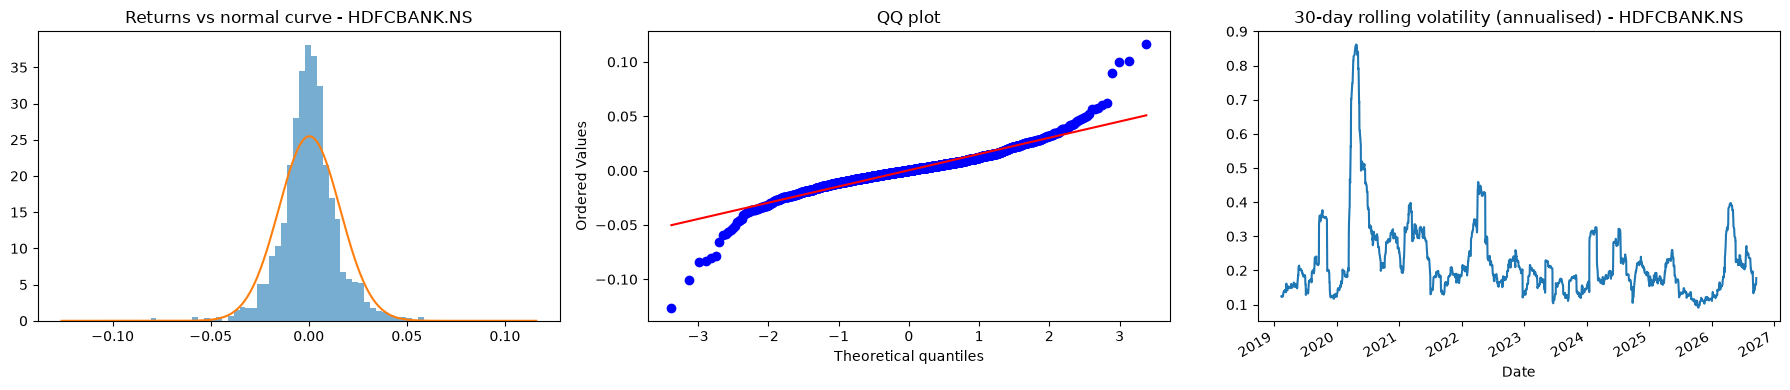

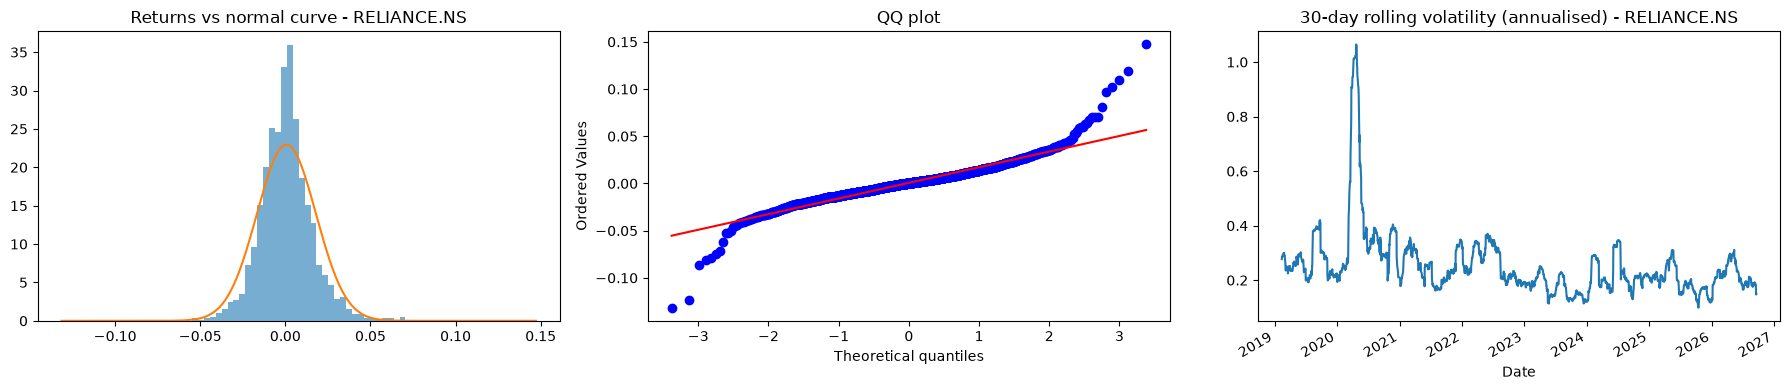

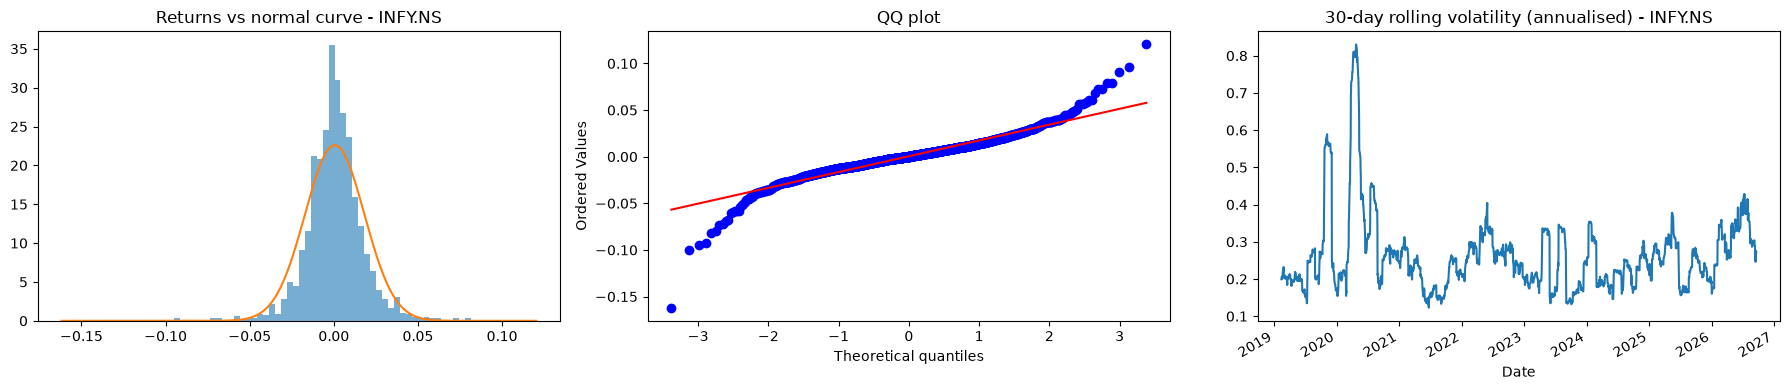

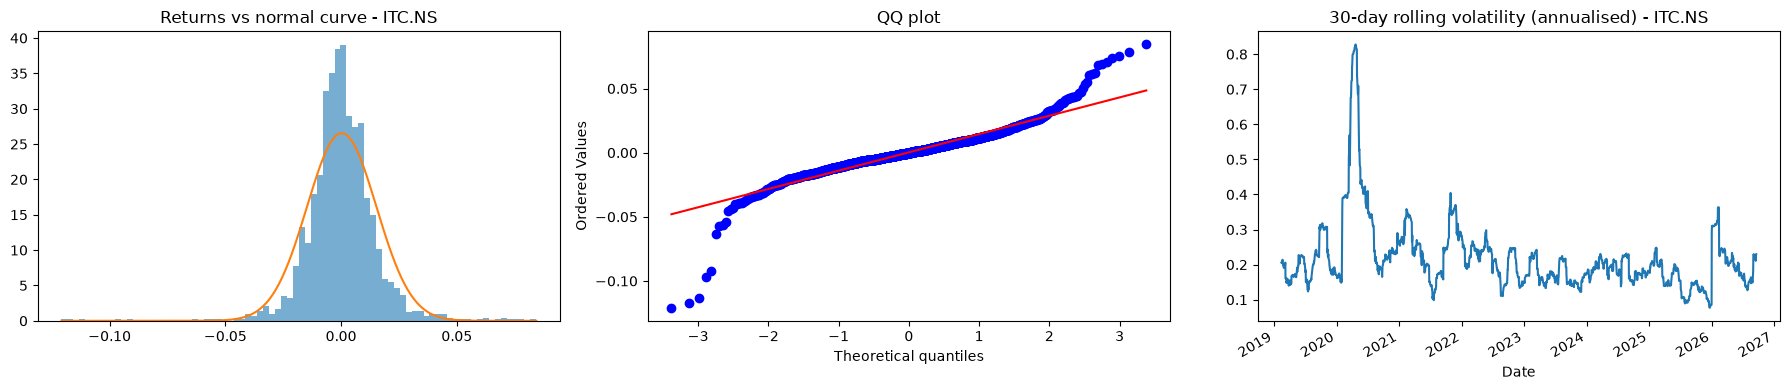

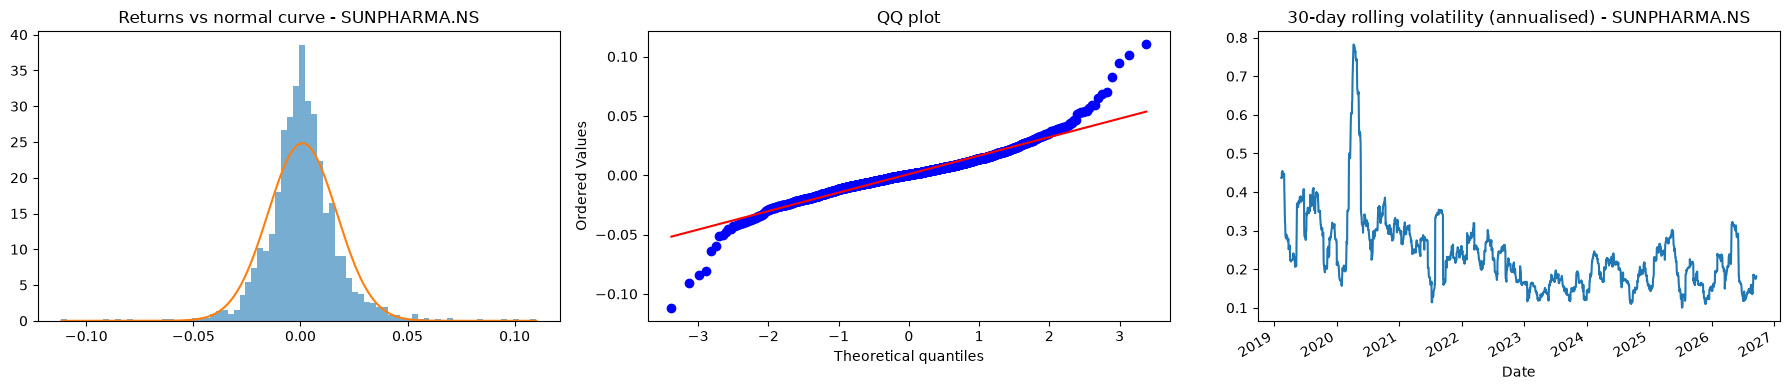

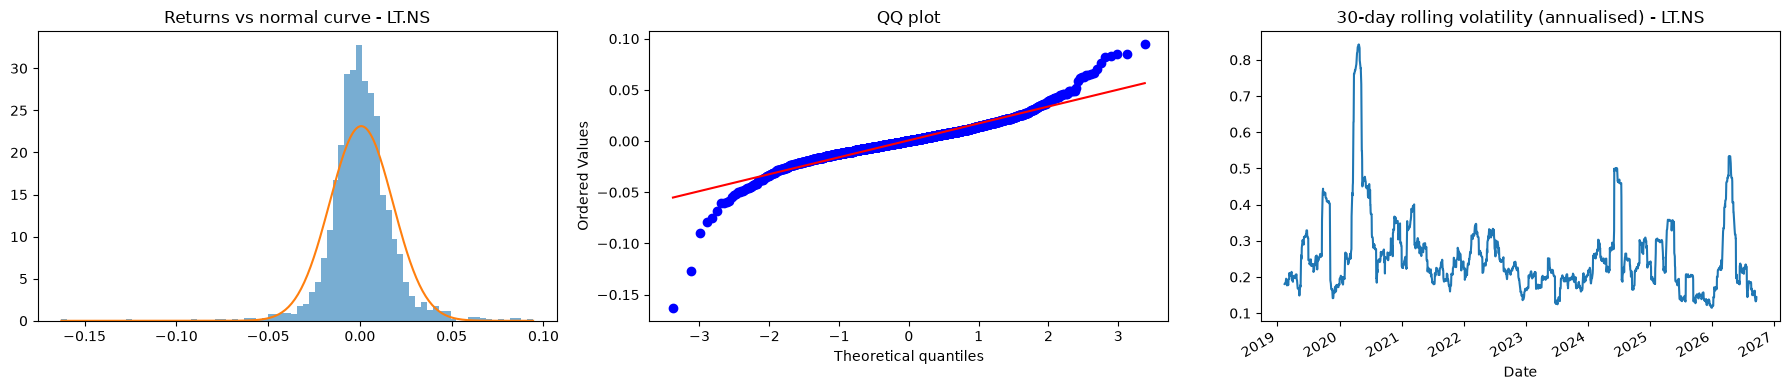

In [7]:

for t in tickers:
    r = returns[t]

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    # 1) Histogram vs normal curve
    ax[0].hist(r, bins=80, density=True, alpha=0.6)
    x = np.linspace(r.min(), r.max(), 300)
    ax[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()))
    ax[0].set_title(f"Returns vs normal curve - {t}")

    # 2) QQ plot
    stats.probplot(r, dist="norm", plot=ax[1])
    ax[1].set_title("QQ plot")

    # 3) Rolling volatility
    (returns[t].rolling(30).std() * np.sqrt(252)).plot(ax=ax[2], legend=False)
    ax[2].set_title(f"30-day rolling volatility (annualised) - {t}")

    plt.tight_layout()
    plt.show()

In [8]:
min_r = []
index_min = []
count = []
for t in tickers:
    min_r.append(returns[t].min()*100)
    index_min.append(returns[t].idxmin())
    count.append((returns[t].abs() > 4 * returns[t].std()).sum())

In [9]:
for t, min_r, index_min in zip(tickers, min_r, index_min):
    print(f"Min return: {min_r:.2f}% on {index_min.date()} for {t}")

Min return: -12.61% on 2020-03-23 for HDFCBANK.NS
Min return: -13.15% on 2020-03-23 for RELIANCE.NS
Min return: -16.19% on 2019-10-22 for INFY.NS
Min return: -12.08% on 2020-03-23 for ITC.NS
Min return: -11.16% on 2020-03-23 for SUNPHARMA.NS
Min return: -16.27% on 2020-03-23 for LT.NS


In [10]:
# Expected number of 4-sigma days if returns were normal
n_days = len(returns)
expected = n_days * 2 * (1 - stats.norm.cdf(4))
print(n_days, round(expected, 2))

1910 0.12


In [11]:
# When did the extreme days happen?
for s in returns.columns:
    r = returns[s]
    extreme_days = r[r.abs() > 4 * r.std()]
    print(s, [d.strftime("%Y-%m-%d") for d in extreme_days.index])

HDFCBANK.NS ['2019-09-20', '2020-03-12', '2020-03-16', '2020-03-18', '2020-03-23', '2020-03-25', '2020-03-30', '2020-04-07', '2020-05-04', '2022-04-04', '2024-01-17']
INFY.NS ['2019-07-15', '2019-10-22', '2020-03-12', '2020-03-16', '2020-03-20', '2020-03-23', '2020-03-24', '2020-04-07', '2020-07-16', '2022-04-18', '2023-04-17', '2023-07-21', '2024-01-12', '2025-05-12', '2026-02-04']
ITC.NS ['2019-09-23', '2020-02-03', '2020-03-12', '2020-03-16', '2020-03-19', '2020-03-20', '2020-03-23', '2020-03-26', '2020-03-31', '2020-04-03', '2020-05-21', '2021-02-01', '2021-02-04', '2021-09-16', '2021-10-19', '2026-01-01']
LT.NS ['2019-09-20', '2019-09-23', '2020-03-12', '2020-03-16', '2020-03-23', '2020-03-25', '2020-03-26', '2020-11-10', '2021-02-01', '2024-06-04', '2026-03-13', '2026-04-08']
RELIANCE.NS ['2019-08-13', '2020-03-09', '2020-03-12', '2020-03-16', '2020-03-20', '2020-03-23', '2020-03-25', '2020-03-31', '2020-04-07', '2020-04-22', '2020-08-04', '2020-09-10', '2020-11-02', '2022-07-01'